In [1]:
import pandas as pd #Veri tablolarını okumak ve düzenlemek için kullanılır.
import matplotlib.pyplot as plt #Grafiklerin temel yapısını oluşturmak içi kullanılır
import seaborn as sns #Grafiklerin daha görsel ve anlaşılır olması için kullanılır.
from sklearn.model_selection import train_test_split #Veriyi eğitim ve test olarak bölmek için kullanılır.
from sklearn.ensemble import GradientBoostingClassifier #Gradyan artırmalı ağaç algoritmasını çağırmak için kullanılır.
from sklearn.metrics import classification_report, accuracy_score #Model başarısını ölçmek için kullanılan metriklerdir.

print("Kütüphaneler başarıyla yüklendi...") #İşlemin bittiğini anlamamız için bir mesaj yazdırdık.

Kütüphaneler başarıyla yüklendi...


In [2]:
#Dosyayı sistemden okuyup 'df' değişkenine atıyoruz
df = pd.read_excel('22nisanverileri.xlsx')
#Veri tablosunun ilk 5 satırını ekrana getirerek kontrol ediyoruz.
df.head()
#Veri setinde kaç satır ve sütun olduğunu kontrol ediyoruz.
print(f"Veri Boyutu: {df.shape}")

Veri Boyutu: (2529, 28)


In [3]:
# .iloc[:, :27] komutu ile ilk 27 sütunu (0'dan 26'ya kadar) 'X' yani özellikler olarak alıyoruz.
X = df.iloc[:,:27]
# .iloc[:, 27] komutu ile tam olarak 28. sütunu (indeks 27) 'y' yani tahmin edilecek hedef olarak alıyoruz.
y = df.iloc[:, 27]
# Ayrılan verilerin boyutlarını kontrol ederek hata olup olmadığına bakıyoruz.
print("Girdiler (X) ve Hedef (y) başarıyla ayrıldı.")

Girdiler (X) ve Hedef (y) başarıyla ayrıldı.


In [4]:
# train_test_split fonksiyonu ile veriyi karıştırıp bölüyoruz.
# test_size=0.2 -> Verinin %20'sini test, %80'ini eğitim için ayırır.
# random_state=42 -> Her çalıştırmada aynı rastgele sonucu almamızı sağlar.
# stratify=y -> Eğitim ve test setindeki hedef dağılım oranını korur.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Bölünen veri parçalarının sayılarını yazdırıyoruz.
print(f"Eğitim seti boyutu: {len(X_train)}") 
print(f"Test seti boyutu: {len(X_test)}")

Eğitim seti boyutu: 2023
Test seti boyutu: 506


In [5]:
# Gradyan Artırmalı Ağaçlar modelini oluşturuyoruz.
# n_estimators=100 -> Modelde kullanılacak toplam karar ağacı sayısı.
# learning_rate=0.1 -> Modelin öğrenme hızı (Hataları düzeltme katsayısı).
# max_depth=3 -> Her bir ağacın aşağıya doğru kaç katmanlı olacağı.
model = GradientBoostingClassifier(n_estimators=100
                                   ,learning_rate=0.1
                                   ,max_depth=3
                                   ,random_state=42)

# model.fit komutu ile makineye X_train verilerini gösterip y_train sonuçlarını öğrenmesini söylüyoruz.
model.fit(X_train, y_train)

# Eğitimin bittiğini belirten mesaj.
print("Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.")

Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.


In [6]:
# model.predict ile makineye daha önce görmediği test verilerini (X_test) soruyoruz.
y_pred = model.predict(X_test)

# accuracy_score ile makinenin doğru tahmin oranını hesaplıyoruz.
skor = accuracy_score(y_test, y_pred) 

# Sonucu ekrana yüzde formatında yazdırıyoruz.
print(f"Modelin Genel Başarı Oranı: %{skor*100:.2f}") 

# Detaylı sınıflandırma raporunu (Hangi sınıfta ne kadar hata yaptı) yazdırıyoruz.
print("\n--- Detaylı Performans Raporu ---")
print(classification_report(y_test, y_pred))

Modelin Genel Başarı Oranı: %89.13

--- Detaylı Performans Raporu ---
              precision    recall  f1-score   support

           0       0.91      0.97      0.93       408
           1       0.80      0.58      0.67        98

    accuracy                           0.89       506
   macro avg       0.85      0.77      0.80       506
weighted avg       0.89      0.89      0.88       506



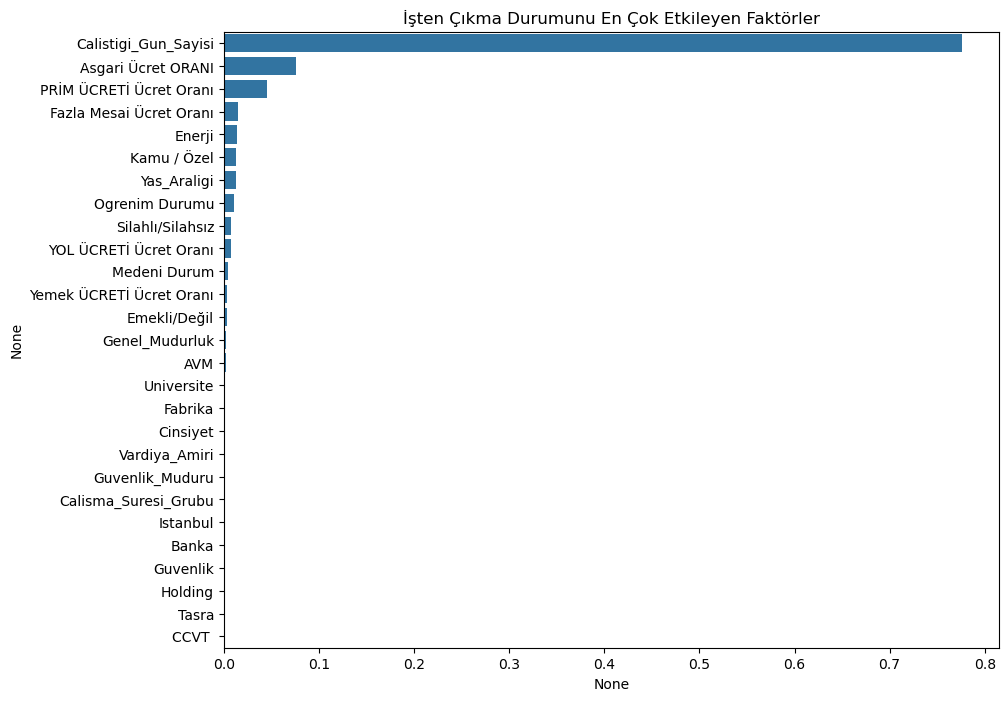

In [7]:
# model.feature_importances_ özelliği ile hangi sütunun kararda ne kadar etkili olduğunu alıyoruz.
onem_sirasi = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Grafik çerçeve boyutunu belirliyoruz.
plt.figure(figsize=(10, 8)) 

# Seaborn kütüphanesi ile sütun grafiğini (bar plot) çizdiriyoruz.
sns.barplot(x=onem_sirasi, y=onem_sirasi.index) 

# Grafiğe başlık ekliyoruz.
plt.title("İşten Çıkma Durumunu En Çok Etkileyen Faktörler") 

# Grafiği ekranda gösteriyoruz.
plt.show()

In [8]:
# Gradyan Artırmalı Ağaçlar modelini oluşturuyoruz.
# n_estimators=100 -> Modelde kullanılacak toplam karar ağacı sayısı.
# learning_rate=0.1 -> Modelin öğrenme hızı (Hataları düzeltme katsayısı).
# max_depth=3 -> Her bir ağacın aşağıya doğru kaç katmanlı olacağı.
model = GradientBoostingClassifier(n_estimators=100
                                   ,learning_rate=0.1
                                   ,max_depth=3
                                   ,random_state=42)

# model.fit komutu ile makineye X_train verilerini gösterip y_train sonuçlarını öğrenmesini söylüyoruz.
model.fit(X_train, y_train)

# Eğitimin bittiğini belirten mesaj.
print("Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.")

Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.


In [9]:
# model.predict ile makineye daha önce görmediği test verilerini (X_test) soruyoruz.
y_pred = model.predict(X_test)

# accuracy_score ile makinenin doğru tahmin oranını hesaplıyoruz.
skor = accuracy_score(y_test, y_pred) 

# Sonucu ekrana yüzde formatında yazdırıyoruz.
print(f"Modelin Genel Başarı Oranı: %{skor*100:.2f}") 

# Detaylı sınıflandırma raporunu (Hangi sınıfta ne kadar hata yaptı) yazdırıyoruz.
print("\n--- Detaylı Performans Raporu ---")
print(classification_report(y_test, y_pred))

Modelin Genel Başarı Oranı: %89.13

--- Detaylı Performans Raporu ---
              precision    recall  f1-score   support

           0       0.91      0.97      0.93       408
           1       0.80      0.58      0.67        98

    accuracy                           0.89       506
   macro avg       0.85      0.77      0.80       506
weighted avg       0.89      0.89      0.88       506



In [10]:
# Gradyan Artırmalı Ağaçlar modelini oluşturuyoruz.
# n_estimators=100 -> Modelde kullanılacak toplam karar ağacı sayısı.
# learning_rate=0.1 -> Modelin öğrenme hızı (Hataları düzeltme katsayısı).
# max_depth=3 -> Her bir ağacın aşağıya doğru kaç katmanlı olacağı.
model = GradientBoostingClassifier(n_estimators=500
                                   ,learning_rate=0.1
                                   ,max_depth=3
                                   ,random_state=42)

# model.fit komutu ile makineye X_train verilerini gösterip y_train sonuçlarını öğrenmesini söylüyoruz.
model.fit(X_train, y_train)

# Eğitimin bittiğini belirten mesaj.
print("Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.")

Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.


In [11]:
# model.predict ile makineye daha önce görmediği test verilerini (X_test) soruyoruz.
y_pred = model.predict(X_test)

# accuracy_score ile makinenin doğru tahmin oranını hesaplıyoruz.
skor = accuracy_score(y_test, y_pred) 

# Sonucu ekrana yüzde formatında yazdırıyoruz.
print(f"Modelin Genel Başarı Oranı: %{skor*100:.2f}") 

# Detaylı sınıflandırma raporunu (Hangi sınıfta ne kadar hata yaptı) yazdırıyoruz.
print("\n--- Detaylı Performans Raporu ---")
print(classification_report(y_test, y_pred))

Modelin Genel Başarı Oranı: %89.33

--- Detaylı Performans Raporu ---
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       408
           1       0.79      0.61      0.69        98

    accuracy                           0.89       506
   macro avg       0.85      0.79      0.81       506
weighted avg       0.89      0.89      0.89       506



In [12]:
# Gradyan Artırmalı Ağaçlar modelini oluşturuyoruz.
# n_estimators=100 -> Modelde kullanılacak toplam karar ağacı sayısı.
# learning_rate=0.1 -> Modelin öğrenme hızı (Hataları düzeltme katsayısı).
# max_depth=3 -> Her bir ağacın aşağıya doğru kaç katmanlı olacağı.
model = GradientBoostingClassifier(n_estimators=500
                                   ,learning_rate=0.05
                                   ,max_depth=3
                                   ,random_state=42)

# model.fit komutu ile makineye X_train verilerini gösterip y_train sonuçlarını öğrenmesini söylüyoruz.
model.fit(X_train, y_train)

# Eğitimin bittiğini belirten mesaj.
print("Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.")

Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.


In [13]:
# model.predict ile makineye daha önce görmediği test verilerini (X_test) soruyoruz.
y_pred = model.predict(X_test)

# accuracy_score ile makinenin doğru tahmin oranını hesaplıyoruz.
skor = accuracy_score(y_test, y_pred) 

# Sonucu ekrana yüzde formatında yazdırıyoruz.
print(f"Modelin Genel Başarı Oranı: %{skor*100:.2f}") 

# Detaylı sınıflandırma raporunu (Hangi sınıfta ne kadar hata yaptı) yazdırıyoruz.
print("\n--- Detaylı Performans Raporu ---")
print(classification_report(y_test, y_pred))

Modelin Genel Başarı Oranı: %88.54

--- Detaylı Performans Raporu ---
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       408
           1       0.78      0.57      0.66        98

    accuracy                           0.89       506
   macro avg       0.84      0.77      0.79       506
weighted avg       0.88      0.89      0.88       506



In [14]:
# Gradyan Artırmalı Ağaçlar modelini oluşturuyoruz.
# n_estimators=100 -> Modelde kullanılacak toplam karar ağacı sayısı.
# learning_rate=0.1 -> Modelin öğrenme hızı (Hataları düzeltme katsayısı).
# max_depth=3 -> Her bir ağacın aşağıya doğru kaç katmanlı olacağı.
model = GradientBoostingClassifier(n_estimators=500
                                   ,learning_rate=0.1
                                   ,max_depth=4
                                   ,random_state=42)

# model.fit komutu ile makineye X_train verilerini gösterip y_train sonuçlarını öğrenmesini söylüyoruz.
model.fit(X_train, y_train)

# Eğitimin bittiğini belirten mesaj.
print("Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.")

Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.


In [15]:
# model.predict ile makineye daha önce görmediği test verilerini (X_test) soruyoruz.
y_pred = model.predict(X_test)

# accuracy_score ile makinenin doğru tahmin oranını hesaplıyoruz.
skor = accuracy_score(y_test, y_pred) 

# Sonucu ekrana yüzde formatında yazdırıyoruz.
print(f"Modelin Genel Başarı Oranı: %{skor*100:.2f}") 

# Detaylı sınıflandırma raporunu (Hangi sınıfta ne kadar hata yaptı) yazdırıyoruz.
print("\n--- Detaylı Performans Raporu ---")
print(classification_report(y_test, y_pred))

Modelin Genel Başarı Oranı: %88.34

--- Detaylı Performans Raporu ---
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       408
           1       0.73      0.62      0.67        98

    accuracy                           0.88       506
   macro avg       0.82      0.78      0.80       506
weighted avg       0.88      0.88      0.88       506



In [16]:
# Gradyan Artırmalı Ağaçlar modelini oluşturuyoruz.
# n_estimators=100 -> Modelde kullanılacak toplam karar ağacı sayısı.
# learning_rate=0.1 -> Modelin öğrenme hızı (Hataları düzeltme katsayısı).
# max_depth=3 -> Her bir ağacın aşağıya doğru kaç katmanlı olacağı.
model = GradientBoostingClassifier(n_estimators=500
                                   ,learning_rate=0.1
                                   ,max_depth=5
                                   ,random_state=42)

# model.fit komutu ile makineye X_train verilerini gösterip y_train sonuçlarını öğrenmesini söylüyoruz.
model.fit(X_train, y_train)

# Eğitimin bittiğini belirten mesaj.
print("Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.")

Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.


In [17]:
# model.predict ile makineye daha önce görmediği test verilerini (X_test) soruyoruz.
y_pred = model.predict(X_test)

# accuracy_score ile makinenin doğru tahmin oranını hesaplıyoruz.
skor = accuracy_score(y_test, y_pred) 

# Sonucu ekrana yüzde formatında yazdırıyoruz.
print(f"Modelin Genel Başarı Oranı: %{skor*100:.2f}") 

# Detaylı sınıflandırma raporunu (Hangi sınıfta ne kadar hata yaptı) yazdırıyoruz.
print("\n--- Detaylı Performans Raporu ---")
print(classification_report(y_test, y_pred))

Modelin Genel Başarı Oranı: %88.93

--- Detaylı Performans Raporu ---
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       408
           1       0.74      0.66      0.70        98

    accuracy                           0.89       506
   macro avg       0.83      0.80      0.82       506
weighted avg       0.89      0.89      0.89       506



In [18]:
# Gradyan Artırmalı Ağaçlar modelini oluşturuyoruz.
# n_estimators=100 -> Modelde kullanılacak toplam karar ağacı sayısı.
# learning_rate=0.1 -> Modelin öğrenme hızı (Hataları düzeltme katsayısı).
# max_depth=3 -> Her bir ağacın aşağıya doğru kaç katmanlı olacağı.
model = GradientBoostingClassifier(n_estimators=500
                                   ,learning_rate=0.01
                                   ,max_depth=5
                                   ,random_state=42)

# model.fit komutu ile makineye X_train verilerini gösterip y_train sonuçlarını öğrenmesini söylüyoruz.
model.fit(X_train, y_train)

# Eğitimin bittiğini belirten mesaj.
print("Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.")

Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.


In [19]:
# model.predict ile makineye daha önce görmediği test verilerini (X_test) soruyoruz.
y_pred = model.predict(X_test)

# accuracy_score ile makinenin doğru tahmin oranını hesaplıyoruz.
skor = accuracy_score(y_test, y_pred) 

# Sonucu ekrana yüzde formatında yazdırıyoruz.
print(f"Modelin Genel Başarı Oranı: %{skor*100:.2f}") 

# Detaylı sınıflandırma raporunu (Hangi sınıfta ne kadar hata yaptı) yazdırıyoruz.
print("\n--- Detaylı Performans Raporu ---")
print(classification_report(y_test, y_pred))

Modelin Genel Başarı Oranı: %88.54

--- Detaylı Performans Raporu ---
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       408
           1       0.76      0.60      0.67        98

    accuracy                           0.89       506
   macro avg       0.83      0.78      0.80       506
weighted avg       0.88      0.89      0.88       506



In [20]:
# Gradyan Artırmalı Ağaçlar modelini oluşturuyoruz.
# n_estimators=100 -> Modelde kullanılacak toplam karar ağacı sayısı.
# learning_rate=0.1 -> Modelin öğrenme hızı (Hataları düzeltme katsayısı).
# max_depth=3 -> Her bir ağacın aşağıya doğru kaç katmanlı olacağı.
model = GradientBoostingClassifier(n_estimators=1000
                                   ,learning_rate=0.1
                                   ,max_depth=5
                                   ,random_state=42)

# model.fit komutu ile makineye X_train verilerini gösterip y_train sonuçlarını öğrenmesini söylüyoruz.
model.fit(X_train, y_train)

# Eğitimin bittiğini belirten mesaj.
print("Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.")

Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.


In [21]:
# model.predict ile makineye daha önce görmediği test verilerini (X_test) soruyoruz.
y_pred = model.predict(X_test)

# accuracy_score ile makinenin doğru tahmin oranını hesaplıyoruz.
skor = accuracy_score(y_test, y_pred) 

# Sonucu ekrana yüzde formatında yazdırıyoruz.
print(f"Modelin Genel Başarı Oranı: %{skor*100:.2f}") 

# Detaylı sınıflandırma raporunu (Hangi sınıfta ne kadar hata yaptı) yazdırıyoruz.
print("\n--- Detaylı Performans Raporu ---")
print(classification_report(y_test, y_pred))

Modelin Genel Başarı Oranı: %88.34

--- Detaylı Performans Raporu ---
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       408
           1       0.72      0.65      0.68        98

    accuracy                           0.88       506
   macro avg       0.82      0.80      0.81       506
weighted avg       0.88      0.88      0.88       506



In [22]:
# Gradyan Artırmalı Ağaçlar modelini oluşturuyoruz.
# n_estimators=100 -> Modelde kullanılacak toplam karar ağacı sayısı.
# learning_rate=0.1 -> Modelin öğrenme hızı (Hataları düzeltme katsayısı).
# max_depth=3 -> Her bir ağacın aşağıya doğru kaç katmanlı olacağı.
model = GradientBoostingClassifier(n_estimators=300
                                   ,learning_rate=0.1
                                   ,max_depth=5
                                   ,random_state=42)

# model.fit komutu ile makineye X_train verilerini gösterip y_train sonuçlarını öğrenmesini söylüyoruz.
model.fit(X_train, y_train)

# Eğitimin bittiğini belirten mesaj.
print("Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.")

Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.


In [23]:
# model.predict ile makineye daha önce görmediği test verilerini (X_test) soruyoruz.
y_pred = model.predict(X_test)

# accuracy_score ile makinenin doğru tahmin oranını hesaplıyoruz.
skor = accuracy_score(y_test, y_pred) 

# Sonucu ekrana yüzde formatında yazdırıyoruz.
print(f"Modelin Genel Başarı Oranı: %{skor*100:.2f}") 

# Detaylı sınıflandırma raporunu (Hangi sınıfta ne kadar hata yaptı) yazdırıyoruz.
print("\n--- Detaylı Performans Raporu ---")
print(classification_report(y_test, y_pred))

Modelin Genel Başarı Oranı: %88.93

--- Detaylı Performans Raporu ---
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       408
           1       0.74      0.66      0.70        98

    accuracy                           0.89       506
   macro avg       0.83      0.80      0.82       506
weighted avg       0.89      0.89      0.89       506



In [24]:
# Gradyan Artırmalı Ağaçlar modelini oluşturuyoruz.
# n_estimators=100 -> Modelde kullanılacak toplam karar ağacı sayısı.
# learning_rate=0.1 -> Modelin öğrenme hızı (Hataları düzeltme katsayısı).
# max_depth=3 -> Her bir ağacın aşağıya doğru kaç katmanlı olacağı.
model = GradientBoostingClassifier(n_estimators=300
                                   ,learning_rate=0.05
                                   ,max_depth=4
                                   ,random_state=42)

# model.fit komutu ile makineye X_train verilerini gösterip y_train sonuçlarını öğrenmesini söylüyoruz.
model.fit(X_train, y_train)

# Eğitimin bittiğini belirten mesaj.
print("Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.")

Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.


In [25]:
# model.predict ile makineye daha önce görmediği test verilerini (X_test) soruyoruz.
y_pred = model.predict(X_test)

# accuracy_score ile makinenin doğru tahmin oranını hesaplıyoruz.
skor = accuracy_score(y_test, y_pred) 

# Sonucu ekrana yüzde formatında yazdırıyoruz.
print(f"Modelin Genel Başarı Oranı: %{skor*100:.2f}") 

# Detaylı sınıflandırma raporunu (Hangi sınıfta ne kadar hata yaptı) yazdırıyoruz.
print("\n--- Detaylı Performans Raporu ---")
print(classification_report(y_test, y_pred))

Modelin Genel Başarı Oranı: %89.33

--- Detaylı Performans Raporu ---
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       408
           1       0.80      0.60      0.69        98

    accuracy                           0.89       506
   macro avg       0.85      0.78      0.81       506
weighted avg       0.89      0.89      0.89       506



In [26]:
# Gradyan Artırmalı Ağaçlar modelini oluşturuyoruz.
# n_estimators=100 -> Modelde kullanılacak toplam karar ağacı sayısı.
# learning_rate=0.1 -> Modelin öğrenme hızı (Hataları düzeltme katsayısı).
# max_depth=3 -> Her bir ağacın aşağıya doğru kaç katmanlı olacağı.
model = GradientBoostingClassifier(n_estimators=300
                                   ,learning_rate=0.05
                                   ,max_depth=4
                                   ,random_state=42)

# model.fit komutu ile makineye X_train verilerini gösterip y_train sonuçlarını öğrenmesini söylüyoruz.
model.fit(X_train, y_train)

# Eğitimin bittiğini belirten mesaj.
print("Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.")

Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.


In [27]:
# model.predict ile makineye daha önce görmediği test verilerini (X_test) soruyoruz.
y_pred = model.predict(X_test)

# accuracy_score ile makinenin doğru tahmin oranını hesaplıyoruz.
skor = accuracy_score(y_test, y_pred) 

# Sonucu ekrana yüzde formatında yazdırıyoruz.
print(f"Modelin Genel Başarı Oranı: %{skor*100:.2f}") 

# Detaylı sınıflandırma raporunu (Hangi sınıfta ne kadar hata yaptı) yazdırıyoruz.
print("\n--- Detaylı Performans Raporu ---")
print(classification_report(y_test, y_pred))

Modelin Genel Başarı Oranı: %89.33

--- Detaylı Performans Raporu ---
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       408
           1       0.80      0.60      0.69        98

    accuracy                           0.89       506
   macro avg       0.85      0.78      0.81       506
weighted avg       0.89      0.89      0.89       506



In [28]:
from sklearn.model_selection import GridSearchCV # En iyi parametreleri bulan araç

# Denemek istediğin seçenekleri bir sözlük (dictionary) olarak yaz
param_grid = {
    'n_estimators': [100, 200, 300, 400,500,600,700,800,900,1000],
    'learning_rate': [0.1, 0.05, 0.01],
    'max_depth': [3, 4, 5]
}

# Modeli bu seçeneklerle test et
# verbose=2 ekleyerek süreci takip edebilirsin
# n_jobs=-1 ekleyerek tüm işlemci gücünü kullanabilirsin
grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42), 
    param_grid, 
    cv=5, 
    n_jobs=-1, 
    verbose=2
)
grid.fit(X_train, y_train)

print(f"En iyi parametreler: {grid.best_params_}")
print(f"En iyi skor: {grid.best_score_}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits
En iyi parametreler: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
En iyi skor: 0.8952047426964919


In [29]:
# Gradyan Artırmalı Ağaçlar modelini oluşturuyoruz.
# n_estimators=100 -> Modelde kullanılacak toplam karar ağacı sayısı.
# learning_rate=0.1 -> Modelin öğrenme hızı (Hataları düzeltme katsayısı).
# max_depth=3 -> Her bir ağacın aşağıya doğru kaç katmanlı olacağı.
model = GradientBoostingClassifier(n_estimators=200
                                   ,learning_rate=0.01
                                   ,max_depth=5
                                   ,random_state=42)

# model.fit komutu ile makineye X_train verilerini gösterip y_train sonuçlarını öğrenmesini söylüyoruz.
model.fit(X_train, y_train)

# Eğitimin bittiğini belirten mesaj.
print("Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.")

Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.


In [30]:
# --- MODEL PERFORMANSINI DEĞERLENDİRME ---

# 1. Eğitim verisi üzerinden tahmin yapıyoruz (Makinenin öğrendiği veriyi ne kadar hatırladığını ölçeriz)
y_train_pred = model.predict(X_train)

# 2. Test verisi üzerinden tahmin yapıyoruz (Makinenin hiç görmediği yeni veride ne kadar başarılı olduğunu ölçeriz)
y_test_pred = model.predict(X_test)

# 3. Eğitim seti için doğruluk oranını hesaplıyoruz
train_skor = accuracy_score(y_train, y_train_pred)

# 4. Test seti için doğruluk oranını hesaplıyoruz
test_skor = accuracy_score(y_test, y_test_pred)

# 5. Sonuçları ekrana yüzde formatında yazdırıyoruz
print(f"Eğitim Seti Başarı Oranı: %{train_skor*100:.2f}")
print(f"Test Seti Başarı Oranı:   %{test_skor*100:.2f}")

# 6. Aradaki farkı kontrol etmek için küçük bir analiz yapıyoruz
print(f"\nBaşarı Farkı (Fark ne kadar azsa o kadar iyi): %{(train_skor - test_skor)*100:.2f}")

# 7. Test verisi için detaylı sınıflandırma raporunu (Precision, Recall vb.) yazdırıyoruz
print("\n--- Test Verisi Detaylı Performans Raporu ---")
print(classification_report(y_test, y_test_pred))
#Burada Recall 0 için 0.96 yani kalanları neredeyse biliyor.

Eğitim Seti Başarı Oranı: %92.78
Test Seti Başarı Oranı:   %88.54

Başarı Farkı (Fark ne kadar azsa o kadar iyi): %4.25

--- Test Verisi Detaylı Performans Raporu ---
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       408
           1       0.77      0.58      0.66        98

    accuracy                           0.89       506
   macro avg       0.84      0.77      0.80       506
weighted avg       0.88      0.89      0.88       506



In [31]:
#Ekstra farklı bir parametre eklemeden en iyi parametreler üzerinden oynama yaparak başarı oranını arttırıp overfittingi azaltmaya çalışıyoruz.
# Mevcut parametreleri daha hassas aralıklarla ve ezber bozucu (regularization) eklemelerle tarıyoruz
param_grid_fine = {
    'n_estimators': [250, 300, 350],         # 200'ün biraz üzerini deniyoruz
    'learning_rate': [0.02, 0.03, 0.05],     # 0.01 çok yavaştı, biraz hızlandırıp dengeyi arıyoruz
    'max_depth': [4, 5, 6],                  # Derinliği 5 civarında tutuyoruz
    'subsample': [0.8, 0.9],                 # Ezberlemeyi (overfitting) engellemek için veriyi rastgele seçtiriyoruz
    'max_features': ['sqrt', 0.8]            # Her ağacın farklı sütunlara odaklanmasını sağlıyoruz
}

# n_jobs=-1 ekleyerek işlemi hızlandırıyoruz
grid_fine = GridSearchCV(
    GradientBoostingClassifier(random_state=42), 
    param_grid_fine, 
    cv=5, 
    n_jobs=-1, 
    verbose=1
)

grid_fine.fit(X_train, y_train)

# Sonuçları Görme
print(f"Yeni En İyi Parametreler: {grid_fine.best_params_}")
print(f"Yeni En İyi Skor (CV): %{grid_fine.best_score_*100:.2f}")

# Final Test Başarısını Ölçme
final_model_v2 = grid_fine.best_estimator_
test_acc = final_model_v2.score(X_test, y_test)
print(f"YENİ TEST BAŞARI ORANI: %{test_acc*100:.2f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Yeni En İyi Parametreler: {'learning_rate': 0.02, 'max_depth': 4, 'max_features': 'sqrt', 'n_estimators': 350, 'subsample': 0.9}
Yeni En İyi Skor (CV): %89.22
YENİ TEST BAŞARI ORANI: %89.13


In [32]:
# Gradyan Artırmalı Ağaçlar modelini oluşturuyoruz.
# n_estimators=100 -> Modelde kullanılacak toplam karar ağacı sayısı.
# learning_rate=0.1 -> Modelin öğrenme hızı (Hataları düzeltme katsayısı).
# max_depth=3 -> Her bir ağacın aşağıya doğru kaç katmanlı olacağı.
model = GradientBoostingClassifier(n_estimators=350
                                   ,learning_rate=0.02
                                   ,max_depth=4
                                   ,max_features = 'sqrt'
                                   ,subsample = 0.9
                                   ,random_state=42)

# model.fit komutu ile makineye X_train verilerini gösterip y_train sonuçlarını öğrenmesini söylüyoruz.
model.fit(X_train, y_train)

# Eğitimin bittiğini belirten mesaj.
print("Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.")

Gradyan Artırmalı Ağaçlar modeli başarıyla eğitildi.


In [33]:
# --- MODEL PERFORMANSINI DEĞERLENDİRME ---

# 1. Eğitim verisi üzerinden tahmin yapıyoruz (Makinenin öğrendiği veriyi ne kadar hatırladığını ölçeriz)
y_train_pred = model.predict(X_train)

# 2. Test verisi üzerinden tahmin yapıyoruz (Makinenin hiç görmediği yeni veride ne kadar başarılı olduğunu ölçeriz)
y_test_pred = model.predict(X_test)

# 3. Eğitim seti için doğruluk oranını hesaplıyoruz
train_skor = accuracy_score(y_train, y_train_pred)

# 4. Test seti için doğruluk oranını hesaplıyoruz
test_skor = accuracy_score(y_test, y_test_pred)

# 5. Sonuçları ekrana yüzde formatında yazdırıyoruz
print(f"Eğitim Seti Başarı Oranı: %{train_skor*100:.2f}")
print(f"Test Seti Başarı Oranı:   %{test_skor*100:.2f}")

# 6. Aradaki farkı kontrol etmek için küçük bir analiz yapıyoruz
print(f"\nBaşarı Farkı (Fark ne kadar azsa o kadar iyi): %{(train_skor - test_skor)*100:.2f}")

# 7. Test verisi için detaylı sınıflandırma raporunu (Precision, Recall vb.) yazdırıyoruz
print("\n--- Test Verisi Detaylı Performans Raporu ---")
print(classification_report(y_test, y_test_pred))

Eğitim Seti Başarı Oranı: %92.73
Test Seti Başarı Oranı:   %89.13

Başarı Farkı (Fark ne kadar azsa o kadar iyi): %3.60

--- Test Verisi Detaylı Performans Raporu ---
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       408
           1       0.78      0.61      0.69        98

    accuracy                           0.89       506
   macro avg       0.85      0.79      0.81       506
weighted avg       0.89      0.89      0.89       506



In [34]:
import numpy as np # Sayısal işlemler ve belirli aralıklarda sayılar üretmek için (np.arange) kullanılır.

# predict_proba fonksiyonu ile modelin doğrudan 0 veya 1 demesini değil, 'yüzde kaç' ihtimal verdiğini alıyoruz.
# [:, 1] ifadesi, listenin ikinci sütununu yani 'İşten Çıkma (1)' olma olasılığını seçer.
y_probs = final_model_v2.predict_proba(X_test)[:, 1]

print("--- Eşik Değeri Denemeleri ---")

# En yüksek başarı oranını ve bunu sağlayan eşik değerini saklamak için boş kutucuklar (değişkenler) oluşturuyoruz.
en_iyi_acc = 0 
en_iyi_esik = 0.5 # Başlangıçta standart olan %50 değerini veriyoruz.

# np.arange(0.3, 0.7, 0.01) komutu; 0.30'dan başlayıp 0.70'e kadar 0.01'lik adımlarla (0.31, 0.32...) bir liste oluşturur.
# Bu döngü, her bir olasılık değerini tek tek denememizi sağlar.
for esik in np.arange(0.3, 0.7, 0.01):
    
    # Eğer modelin verdiği olasılık o an denediğimiz 'esik' değerinden büyükse 1 (çıkar), değilse 0 (kalır) yapıyoruz.
    # .astype(int) komutu True/False sonuçlarını 1 ve 0 sayılarına çevirir.
    gecici_tahmin = (y_probs >= esik).astype(int)
    
    # Oluşturduğumuz bu yeni tahminlerin gerçek sonuçlarla (y_test) ne kadar uyumlu olduğunu ölçüyoruz.
    skor = accuracy_score(y_test, gecici_tahmin)
    
    # Eğer bu döngüdeki skor, şimdiye kadar bulduğumuz en iyi skordan daha yüksekse:
    if skor > en_iyi_acc:
        en_iyi_acc = skor # Yeni rekoru kaydet.
        en_iyi_esik = esik # Rekoru kıran eşik değerini (sayıyı) hafızaya al.

# Döngü bittiğinde ulaşılan en yüksek sonucu ve o sihirli eşik sayısını ekrana yazdırıyoruz.
print(f"En Yüksek Başarı: %{en_iyi_acc*100:.2f}")
print(f"Bunu Sağlayan Eşik Değeri: {en_iyi_esik:.2f}")

--- Eşik Değeri Denemeleri ---
En Yüksek Başarı: %89.92
Bunu Sağlayan Eşik Değeri: 0.44


In [35]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# 1. ADIM: Daha önce bulduğumuz o "sihirli" eşik değerini tanımlıyoruz
# Normalde 0.50 olan bu sınırı, senin verin için en iyi sonucu veren 0.44'e çekiyoruz.
secilen_esik = 0.44

# 2. ADIM: Olasılık Tahminlerini Alıyoruz
# Modelin doğrudan 0 veya 1 demesini değil, her satır için % kaç ihtimal verdiğini alıyoruz.
train_probs = final_model_v2.predict_proba(X_train)[:, 1] # Eğitim seti olasılıkları
test_probs = final_model_v2.predict_proba(X_test)[:, 1]   # Test seti olasılıkları

# 3. ADIM: Eşik Değerini Uyguluyoruz
# Eğer modelin verdiği ihtimal 0.44'ten büyükse 'İşten Çıkar (1)', küçükse 'Kalır (0)' diyoruz.
train_tahminler = (train_probs >= secilen_esik).astype(int)
test_tahminler = (test_probs >= secilen_esik).astype(int)

# 4. ADIM: Başarı Oranlarını Hesaplıyoruz
# Bu yeni tahminlerin gerçek sonuçlarla ne kadar uyumlu olduğuna bakıyoruz.
egitim_basarisi = accuracy_score(y_train, train_tahminler)
test_basarisi = accuracy_score(y_test, test_tahminler)

# 5. ADIM: Sonuçları Ekrana Yazdırıyoruz
print("="*40)
print("   FİNAL MODEL DEĞERLENDİRME RAPORU   ")
print("="*40)
print(f"Kullanılan Eşik Değeri: {secilen_esik}")
print(f"Eğitim Seti Başarı Oranı: %{egitim_basarisi*100:.2f}")
print(f"Test Seti Başarı Oranı:   %{test_basarisi*100:.2f}")
print("-" * 40)

# 6. ADIM: Detaylı Performans Analizi
# Bu rapor bize hangi sınıfta ne kadar başarılı olduğumuzu (Recall, Precision) detaylıca gösterir.
print("YENİ EŞİK DEĞERİNE GÖRE DETAYLI TEST RAPORU:")
print(classification_report(y_test, test_tahminler))

# 7. ADIM: Küçük Bir Karşılaştırma Analizi
fark = egitim_basarisi - test_basarisi
if fark > 0.05:
    print(f"NOT: Aradaki fark (%{fark*100:.2f}) biraz yüksek. Model hala hafifçe ezberliyor olabilir.")
else:
    print(f"NOT: Harika! Aradaki fark (%{fark*100:.2f}) çok düşük. Modelin gayet dengeli ve sağlıklı.")

   FİNAL MODEL DEĞERLENDİRME RAPORU   
Kullanılan Eşik Değeri: 0.44
Eğitim Seti Başarı Oranı: %92.93
Test Seti Başarı Oranı:   %89.92
----------------------------------------
YENİ EŞİK DEĞERİNE GÖRE DETAYLI TEST RAPORU:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       408
           1       0.78      0.67      0.72        98

    accuracy                           0.90       506
   macro avg       0.85      0.81      0.83       506
weighted avg       0.90      0.90      0.90       506

NOT: Harika! Aradaki fark (%3.01) çok düşük. Modelin gayet dengeli ve sağlıklı.
